<a href="https://colab.research.google.com/github/Immortalcoder0/InsightShelf/blob/main/Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

# Construct the path to the CSV file (using the provided file location)
csv_file_path = '/content/dataset.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

print("Missing values before removal:\n", df.isnull().sum())

df = df.dropna()

print("\nMissing values after removal:\n", df.isnull().sum())

print(f"DataFrame shape after removing missing values: {df.shape}")

Missing values before removal:
 StudentID     0
Department    0
BookID        0
Category      2
BorrowDate    0
ReturnDate    5
dtype: int64

Missing values after removal:
 StudentID     0
Department    0
BookID        0
Category      0
BorrowDate    0
ReturnDate    0
dtype: int64
DataFrame shape after removing missing values: (419, 6)


## Normalize Date Formats


In [ ]:
print("Original data types of date columns:")
print(df[['BorrowDate', 'ReturnDate']].dtypes)

# Convert 'BorrowDate' and 'ReturnDate' columns to datetime objects
df['BorrowDate'] = pd.to_datetime(df['BorrowDate'], errors='coerce')
df['ReturnDate'] = pd.to_datetime(df['ReturnDate'], errors='coerce')

print("\nData types after conversion:")
print(df[['BorrowDate', 'ReturnDate']].dtypes)



Original data types of date columns:
BorrowDate    object
ReturnDate    object
dtype: object

Data types after conversion:
BorrowDate    datetime64[ns]
ReturnDate    datetime64[ns]
dtype: object


In [ ]:
print("First 5 rows of the cleaned DataFrame:")
display(df.head())

First 5 rows of the cleaned DataFrame:


,StudentID,Department,BookID,Category,BorrowDate,ReturnDate
0,S1024,CSE,B402,Technical,2023-09-01,2023-09-08
1,S1015,ECE,B505,Fiction,2023-09-01,2023-09-04
2,S1032,AIML,B101,Science,2023-09-02,2023-09-12
3,S1008,MECH,B210,Technical,2023-09-02,2023-09-09
4,S1045,CIVIL,B601,Management,2023-09-03,2023-09-13


## Calculate Borrow Duration


In [ ]:
df['BorrowDuration'] = df['ReturnDate'] - df['BorrowDate']

print("First 5 rows with new 'BorrowDuration' column:")
display(df.head())


First 5 rows with new 'BorrowDuration' column:


,StudentID,Department,BookID,Category,BorrowDate,ReturnDate,BorrowDuration
0,S1024,CSE,B402,Technical,2023-09-01,2023-09-08,7 days
1,S1015,ECE,B505,Fiction,2023-09-01,2023-09-04,3 days
2,S1032,AIML,B101,Science,2023-09-02,2023-09-12,10 days
3,S1008,MECH,B210,Technical,2023-09-02,2023-09-09,7 days
4,S1045,CIVIL,B601,Management,2023-09-03,2023-09-13,10 days


## Calculate LibraryScore


In [ ]:
library_score = df.groupby('StudentID').size().reset_index(name='LibraryScore')
print("First 5 rows of LibraryScore:")
display(library_score.head())

First 5 rows of LibraryScore:


,StudentID,LibraryScore
0,S1002,26
1,S1003,25
2,S1005,26
3,S1008,25
4,S1009,1


## Calculate Average Borrow Duration


In [ ]:
df['BorrowDurationDays'] = df['BorrowDuration'].dt.days
avg_borrow_duration = df.groupby('StudentID')['BorrowDurationDays'].mean().reset_index(name='AverageBorrowDuration')

print("First 5 rows of AverageBorrowDuration:")
display(avg_borrow_duration.head())



First 5 rows of AverageBorrowDuration:


,StudentID,AverageBorrowDuration
0,S1002,8.807692
1,S1003,2.960000
2,S1005,9.115385
3,S1008,2.520000
4,S1009,10.000000


In [ ]:
favorite_category = df.groupby('StudentID')['Category'].agg(lambda x: x.mode()[0]).reset_index(name='FavoriteCategory')

print("First 5 rows of FavoriteCategory:")
display(favorite_category.head())

First 5 rows of FavoriteCategory:


,StudentID,FavoriteCategory
0,S1002,Management
1,S1003,Management
2,S1005,Science
3,S1008,Management
4,S1009,Management


In [ ]:
merged_features = library_score.merge(avg_borrow_duration, on='StudentID', how='left')
merged_features = merged_features.merge(favorite_category, on='StudentID', how='left')

print("First 5 rows of the consolidated features DataFrame:")
display(merged_features.head())


First 5 rows of the consolidated features DataFrame:


,StudentID,LibraryScore,AverageBorrowDuration,FavoriteCategory
0,S1002,26,8.807692,Management
1,S1003,25,2.960000,Management
2,S1005,26,9.115385,Science
3,S1008,25,2.520000,Management
4,S1009,1,10.000000,Management


## Prepare Data for Clustering



In [ ]:
# Feature engineering steps should occur before this
features_for_clustering = merged_features[['LibraryScore', 'AverageBorrowDuration']].copy()

print("Missing values in features_for_clustering before removal:")
print(features_for_clustering.isnull().sum())

# Remove rows with any missing values
features_for_clustering.dropna(inplace=True)

print("\nMissing values in features_for_clustering after removal:")
print(features_for_clustering.isnull().sum())

print(f"\nShape of features_for_clustering after cleaning: {features_for_clustering.shape}")
print("\nFirst 5 rows of features_for_clustering:")
display(features_for_clustering.head())

Missing values in features_for_clustering before removal:
LibraryScore             0
AverageBorrowDuration    0
dtype: int64

Missing values in features_for_clustering after removal:
LibraryScore             0
AverageBorrowDuration    0
dtype: int64

Shape of features_for_clustering after cleaning: (17, 2)

First 5 rows of features_for_clustering:


,LibraryScore,AverageBorrowDuration
0,26,8.807692
1,25,2.960000
2,26,9.115385
3,25,2.520000
4,1,10.000000


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
standardized_features = scaler.fit_transform(features_for_clustering)

# Create a new DataFrame for the standardized features
df_standardized = pd.DataFrame(standardized_features, columns=features_for_clustering.columns)

print("First 5 rows of standardized features:")
display(df_standardized)

First 5 rows of standardized features:


,LibraryScore,AverageBorrowDuration
0,0.224052,0.767748
1,0.058448,-1.031797
2,0.224052,0.862436
3,0.058448,-1.167200
4,-3.916039,1.134664
5,0.555259,-0.920572
6,0.555259,-1.140384
7,0.389656,-0.962499
8,0.389656,0.747145
9,0.720863,0.922433


In [ ]:
# Resetting index for a clean merge
full_dataset = merged_features.copy()
# Add prefix to standardized columns to distinguish them
df_standardized_renamed = df_standardized.rename(columns={'LibraryScore': 'LibraryScore_Scaled', 'AverageBorrowDuration': 'AverageBorrowDuration_Scaled'})

# Combine original features with scaled features
# Note: Assuming indices align as we used dropna() consistently
full_dataset = pd.concat([full_dataset.reset_index(drop=True), df_standardized_renamed.reset_index(drop=True)], axis=1)

print("Full dataset with original and scaled features:")
display(full_dataset)

Full dataset with original and scaled features:


,StudentID,LibraryScore,AverageBorrowDuration,FavoriteCategory,LibraryScore_Scaled,AverageBorrowDuration_Scaled
0,S1002,26,8.807692,Management,0.224052,0.767748
1,S1003,25,2.960000,Management,0.058448,-1.031797
2,S1005,26,9.115385,Science,0.224052,0.862436
3,S1008,25,2.520000,Management,0.058448,-1.167200
4,S1009,1,10.000000,Management,-3.916039,1.134664
5,S1011,28,3.321429,Technical,0.555259,-0.920572
6,S1015,28,2.607143,Technical,0.555259,-1.140384
7,S1019,27,3.185185,Fiction,0.389656,-0.962499
8,S1022,27,8.740741,Science,0.389656,0.747145
9,S1024,29,9.310345,Technical,0.720863,0.922433


## Data Visualizations
Below are charts to help understand the library borrowing patterns.

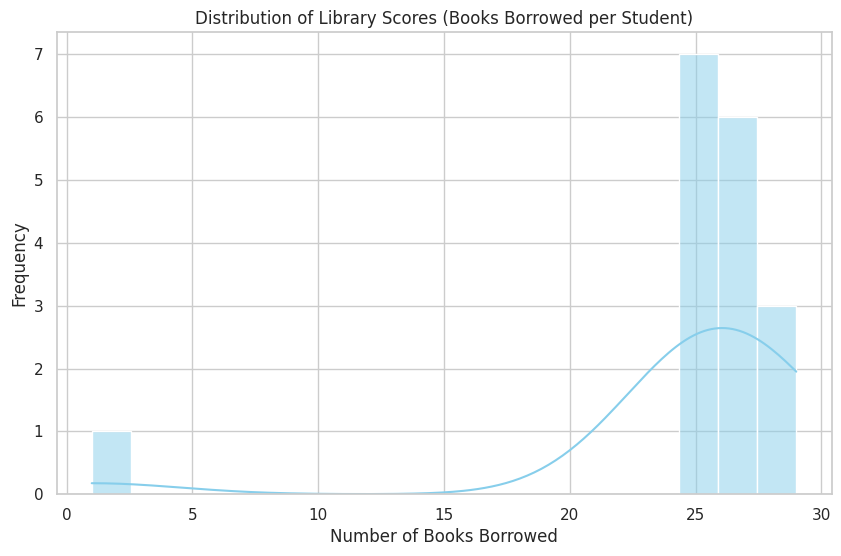

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Distribution of Library Scores
plt.figure(figsize=(10, 6))
sns.histplot(merged_features['LibraryScore'], kde=True, color='skyblue')
plt.title('Distribution of Library Scores (Books Borrowed per Student)')
plt.xlabel('Number of Books Borrowed')
plt.ylabel('Frequency')
plt.show()

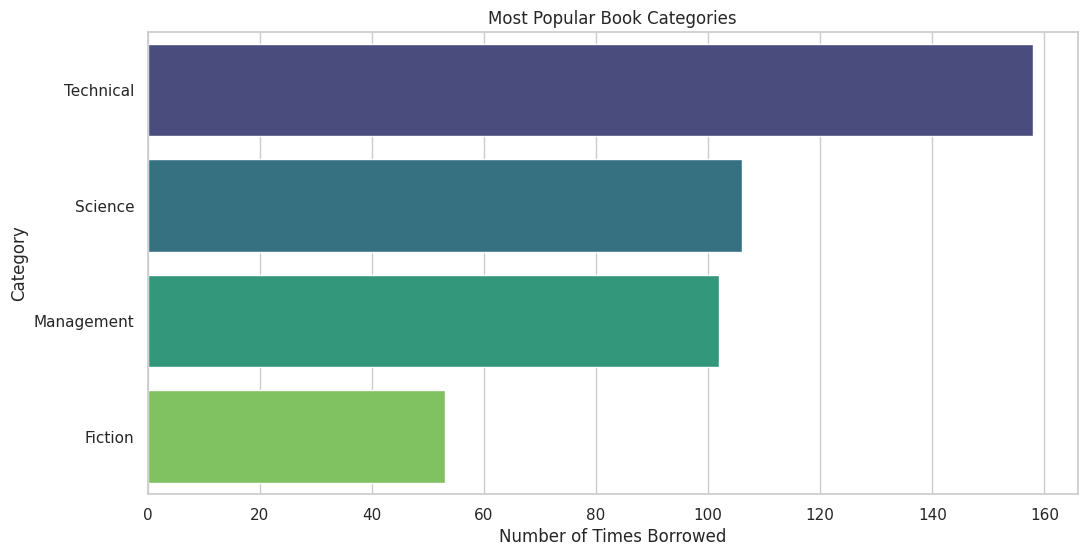

In [ ]:
# 2. Most Popular Book Categories
plt.figure(figsize=(12, 6))
category_counts = df['Category'].value_counts().sort_values(ascending=False)
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis', hue=category_counts.index, legend=False)
plt.title('Most Popular Book Categories')
plt.xlabel('Number of Times Borrowed')
plt.ylabel('Category')
plt.show()

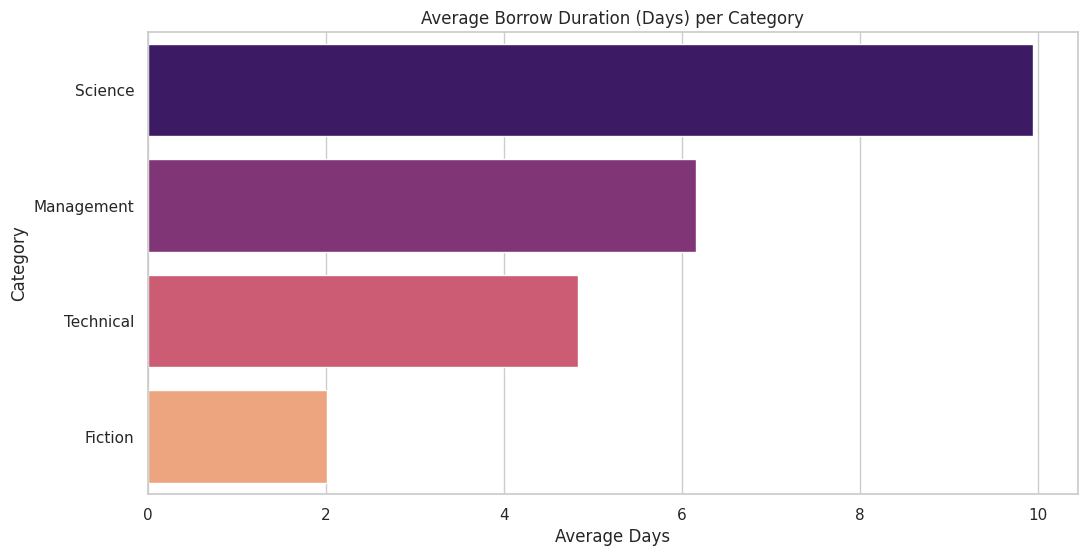

In [ ]:
# 3. Average Borrow Duration by Category
avg_dur_cat = df.groupby('Category')['BorrowDurationDays'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_dur_cat.values, y=avg_dur_cat.index, palette='magma', hue=avg_dur_cat.index, legend=False)
plt.title('Average Borrow Duration (Days) per Category')
plt.xlabel('Average Days')
plt.ylabel('Category')
plt.show()

## Heatmap of Borrowing Patterns

### Subtask:
Create a heatmap using a crosstab of 'Department' and 'Category' from the `df` DataFrame to visualize borrowing activity across different departments.


## K-Means Clustering and Visualization

In this section, we apply K-Means clustering to segment students based on their borrowing frequency (`LibraryScore`) and how long they typically keep books (`AverageBorrowDuration`).

In [ ]:
from sklearn.cluster import KMeans

# We'll use 3 clusters to represent different levels of engagement
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
full_dataset['Cluster'] = kmeans.fit_predict(df_standardized)

# Map cluster numbers to descriptive labels for visualization

cluster_map = {0: 'Occasional Borrowers', 1: 'Consistent Readers', 2: 'Power Users'}
full_dataset['ClusterLabel'] = full_dataset['Cluster'].map(cluster_map)

print("Cluster counts:")
display(full_dataset['ClusterLabel'].value_counts())

display(full_dataset.head())

Cluster counts:


,count
ClusterLabel,
Consistent Readers,8
Occasional Borrowers,8
Power Users,1


,StudentID,LibraryScore,AverageBorrowDuration,FavoriteCategory,LibraryScore_Scaled,AverageBorrowDuration_Scaled,Cluster,ClusterLabel
0,S1002,26,8.807692,Management,0.224052,0.767748,1,Consistent Readers
1,S1003,25,2.960000,Management,0.058448,-1.031797,0,Occasional Borrowers
2,S1005,26,9.115385,Science,0.224052,0.862436,1,Consistent Readers
3,S1008,25,2.520000,Management,0.058448,-1.167200,0,Occasional Borrowers
4,S1009,1,10.000000,Management,-3.916039,1.134664,2,Power Users


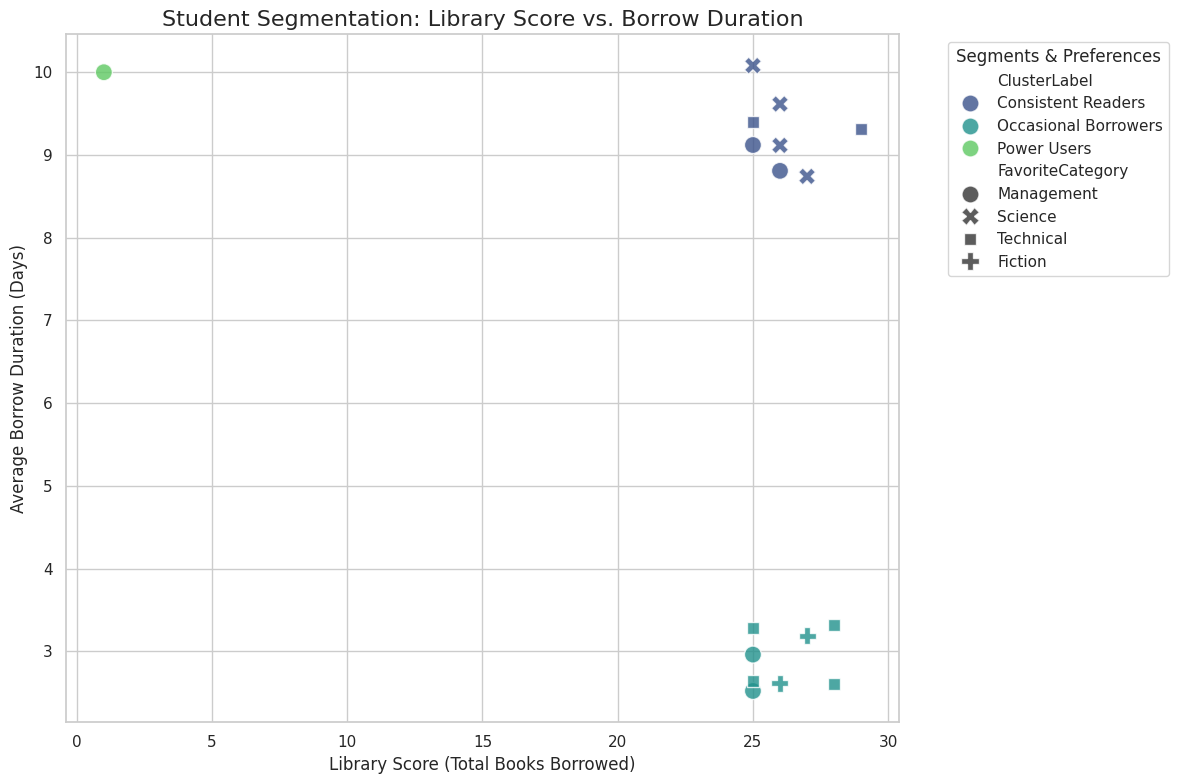

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Create a scatter plot of the clusters
scatter = sns.scatterplot(
    data=full_dataset,
    x='LibraryScore',
    y='AverageBorrowDuration',
    hue='ClusterLabel',
    style='FavoriteCategory',
    palette='viridis',
    s=150,
    alpha=0.8
)

plt.title('Student Segmentation: Library Score vs. Borrow Duration', fontsize=16)
plt.xlabel('Library Score (Total Books Borrowed)', fontsize=12)
plt.ylabel('Average Borrow Duration (Days)', fontsize=12)
plt.legend(title='Segments & Preferences', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Cluster Insights

*   **Cluster Analysis**: The visualization highlights how students naturally group. For instance, 'Power Users' might be those with high scores and long durations, while 'Occasional Borrowers' occupy the lower quadrants.
*   **Preference Overlap**: By using different markers for `FavoriteCategory`, we can see if specific clusters are dominated by certain academic interests (e.g., do Science lovers tend to be Power Users?).

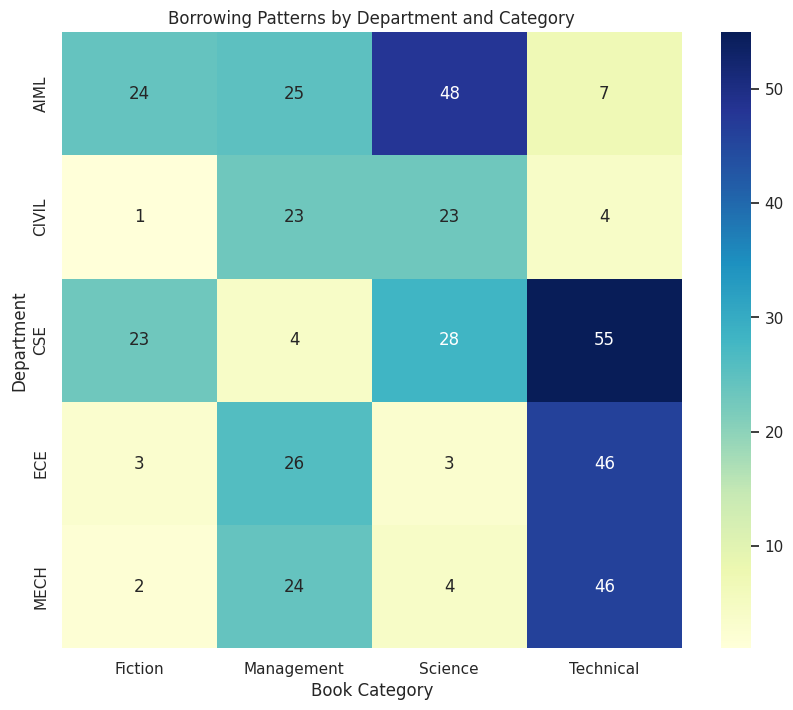

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create a frequency table between 'Department' and 'Category'
borrowing_patterns = pd.crosstab(df['Department'], df['Category'])

# 2. Initialize a matplotlib figure
plt.figure(figsize=(10, 8))

# 3. Create the heatmap
sns.heatmap(borrowing_patterns, annot=True, fmt='d', cmap='YlGnBu')

# 4. Set descriptive title
plt.title('Borrowing Patterns by Department and Category')

# 5. Label axes
plt.xlabel('Book Category')
plt.ylabel('Department')

# 6. Display the plot
plt.show()

## Correlation Analysis

### Subtask:
Generate a scatter plot with a regression line using `sns.lmplot` to analyze the relationship between 'LibraryScore' and 'AverageBorrowDuration' from `full_dataset`, color-coded by 'FavoriteCategory'.


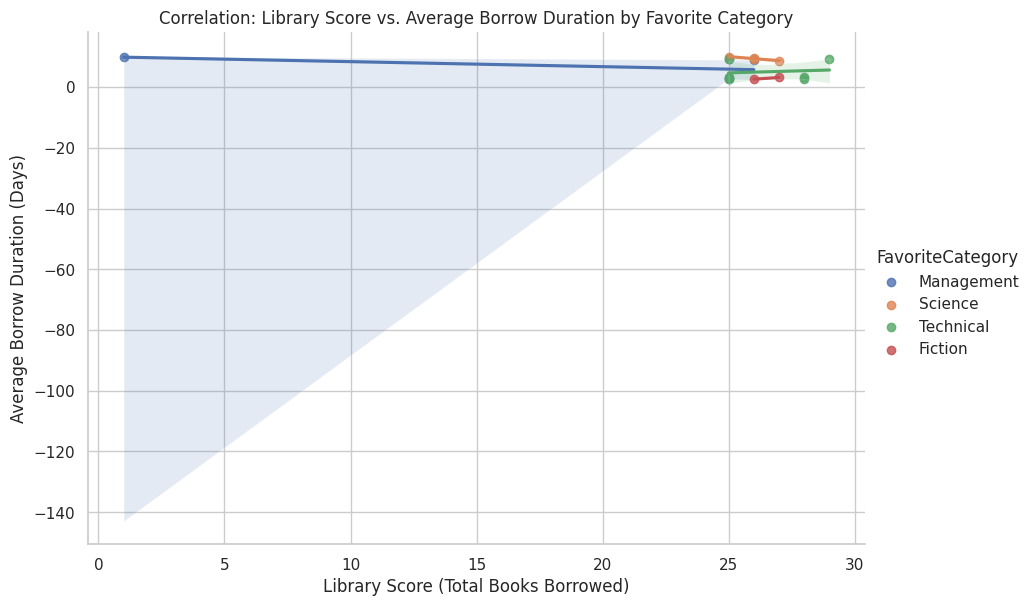

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot with regression lines using sns.lmplot
g = sns.lmplot(
    data=full_dataset,
    x='LibraryScore',
    y='AverageBorrowDuration',
    hue='FavoriteCategory',
    height=6,
    aspect=1.5
)

# Add a descriptive title and label axes
plt.title('Correlation: Library Score vs. Average Borrow Duration by Favorite Category')
g.set_axis_labels('Library Score (Total Books Borrowed)', 'Average Borrow Duration (Days)')

# Display the plot
plt.show()

## Temporal Analysis

### Subtask:
Create a line plot showing monthly borrowing trends by extracting the month from 'BorrowDate' in the 'df' DataFrame.


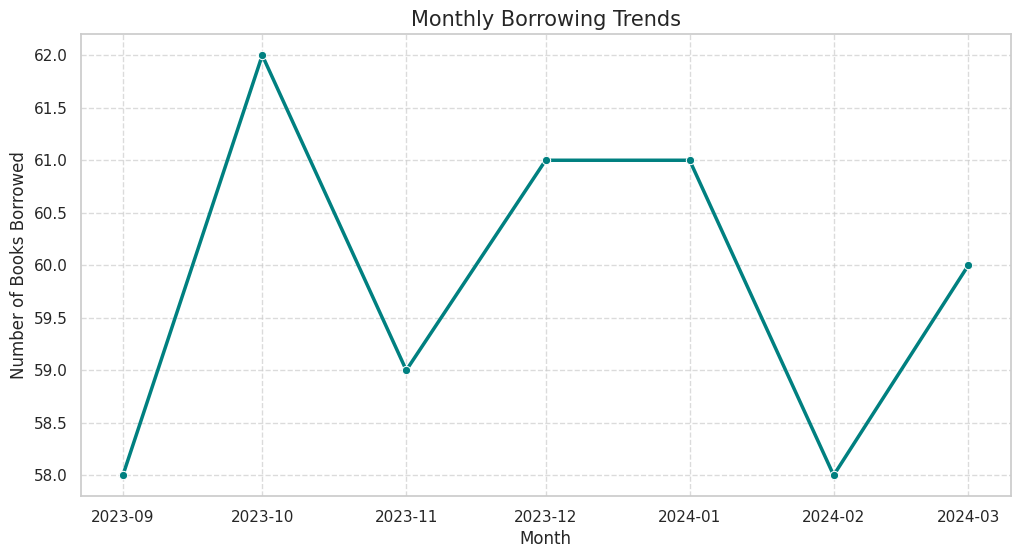

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Ensure BorrowDate is datetime (already done in previous cells, but good to verify)
# df['BorrowDate'] = pd.to_datetime(df['BorrowDate'])

# 2. Extract Year-Month for grouping
df['BorrowMonth'] = df['BorrowDate'].dt.to_period('M').dt.to_timestamp()

# 3. Group by month and count borrowings
monthly_trends = df.groupby('BorrowMonth').size().reset_index(name='BorrowCount')

# 4. Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trends, x='BorrowMonth', y='BorrowCount', marker='o', color='teal', linewidth=2.5)

# 5. Add descriptive title and labels
plt.title('Monthly Borrowing Trends', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Books Borrowed', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

## Categorical Distribution

### Subtask:
Produce a box plot to visualize the distribution of 'BorrowDurationDays' across different 'Categories' to identify variances in loan periods.


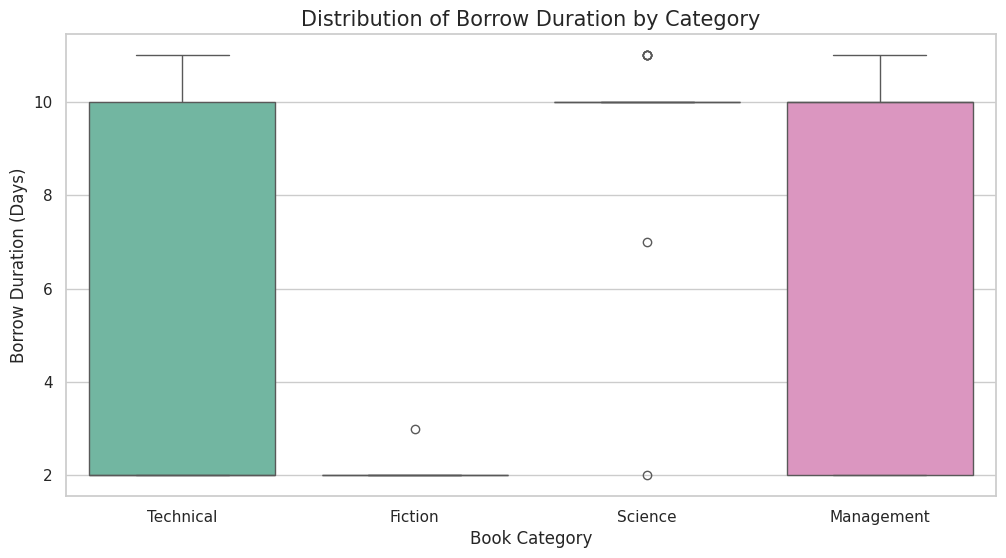

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style and initialize figure
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 2. Create the box plot
sns.boxplot(data=df, x='Category', y='BorrowDurationDays', palette='Set2', hue='Category', legend=False)

# 3. Add descriptive title
plt.title('Distribution of Borrow Duration by Category', fontsize=15)

# 4. Label axes
plt.xlabel('Book Category', fontsize=12)
plt.ylabel('Borrow Duration (Days)', fontsize=12)

# 5. Display the plot
plt.show()